# Air Pollution Emissions vs. Honeybee Colony Change Rates (US, 2024)

**IS 477 — Spring 2026 Project**

## Research question
> Is there a statistically significant correlation between air pollution emissions in each state and honeybee colony changing rates in the United States during 2024–2025?

## Approach
1. We cleaned and aligned both datasets on a common timeline (`Quarter`) and common geography (`State`).
2. We picked the most informative variables from each table:
   - Honeybee colony dynamics: `Colonies`, `Max Colonies`, `Lost`, `Percent Lost`, `Added`, `Renovated`, `Percent Renovated`.
   - Air pollutant observations: `Observation Count`, `Observation Percent`, `Arithmetic Mean` per pollutant.
3. Finally we generated two complementary analyses:
   - **Timeline anchor** — quarterly trajectories aggregated over the US (n = 4 quarters).
   - **State anchor** — pooled state × quarter panel (~50 states × 4 quarters ≈ 200 rows) for higher statistical power.
4. For the statistical tests, we used: Pearson (linear) and Spearman (rank) correlations with p-values.
5. The visualizations include: time series, scatter plots with regression lines, correlation heatmaps, and a state choropleth-style ranking.

## 1. Setup

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

DATA_DIR = Path.cwd()
BEE_CSV = DATA_DIR / "honey_bee_colonies_2025.csv"
POLL_CSV = DATA_DIR / "All Pollutant's Observation Changes from 2024 to 2025.csv"

QUARTER_ORDER = [
    "January-March 2024",
    "April-June 2024",
    "July-September 2024",
    "October-December 2024",
    "January-March 2025",
    "April-June 2025",
]
QUARTERS_2024 = QUARTER_ORDER[:4]

print("Bee CSV:", BEE_CSV.exists(), "|", BEE_CSV.stat().st_size, "bytes")
print("Pollutant CSV:", POLL_CSV.exists(), "|", round(POLL_CSV.stat().st_size / 1e6, 1), "MB")


Bee CSV: True | 14196 bytes
Pollutant CSV: True | 270.7 MB


## 2. Load the honeybee colonies data

In [3]:
bee_raw = pd.read_csv(BEE_CSV)
print("Shape:", bee_raw.shape)
print("Columns:", list(bee_raw.columns))
bee_raw.head()


Shape: (180, 10)
Columns: ['State', 'Start Date', 'Quarter', 'Colonies', 'Max Colonies', 'Lost', 'Percent Lost', 'Added', 'Renovated', 'Percent Renovated']


,State,Start Date,Quarter,Colonies,Max Colonies,Lost,Percent Lost,Added,Renovated,Percent Renovated
0,Alabama,"January 1, 2024",January-March 2024,9500,11000,1600,15,2400.0,860.0,8
1,Arizona,"January 1, 2024",January-March 2024,26000,30000,1900,6,3300.0,670.0,2
2,Arkansas,"January 1, 2024",January-March 2024,16000,21500,1700,8,3260.0,120.0,1
3,California,"January 1, 2024",January-March 2024,940000,1000000,210000,21,250000.0,135000.0,14
4,Colorado,"January 1, 2024",January-March 2024,5500,11000,370,3,500.0,NaN,(X)


In [ ]:
print("Quarters:", bee_raw["Quarter"].unique().tolist())
print("State count:", bee_raw["State"].nunique())
print("Special state labels:", [s for s in bee_raw["State"].unique() if s in {"United States", "Other States"}])


Quarters: ['January-March 2024', 'April-June 2024', 'July-September 2024', 'October-December 2024', 'January-March 2025', 'April-June 2025']
State count: 46
Special state labels: ['Other States', 'United States']


### 2.1 Honeybee dataset nan value pre-cleaning

- `Percent Lost` and `Percent Renovated` use `(X)` ("not applicable") and `(Z)` ("less than 0.5") sentinel codes that pandas reads as strings.
- `Max Colonies` for the `United States` aggregate row is `(X)`.
- The `Other States` rows are misaligned: `Colonies = 5` is a placeholder where columns shifted by one. We drop these rows from per-state analysis.
- We will keep the `United States` rows aside as a national reference series but exclude them from per-state correlations to avoid double counting.


In [ ]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r"\(X\)|\(Z\)", "", regex=True).replace("", np.nan),
        errors="coerce",
    )

bee = bee_raw.copy()
bee = bee[bee["State"] != "Other States"].copy()

for col in ["Colonies", "Max Colonies", "Lost", "Added", "Renovated", "Percent Lost", "Percent Renovated"]:
    bee[col] = clean_numeric(bee[col])

bee["Net Change"] = bee["Added"] - bee["Lost"]
bee["Net Change Rate (%)"] = 100 * bee["Net Change"] / bee["Max Colonies"]
bee["Turnover Rate (%)"] = 100 * (bee["Added"] + bee["Lost"]) / bee["Max Colonies"]

bee["Quarter"] = pd.Categorical(bee["Quarter"], categories=QUARTER_ORDER, ordered=True)
bee = bee.sort_values(["State", "Quarter"]).reset_index(drop=True)

print("After cleaning:", bee.shape)
bee.head()


After cleaning: (174, 13)


,State,Start Date,Quarter,Colonies,Max Colonies,Lost,Percent Lost,Added,Renovated,Percent Renovated,Net Change,Net Change Rate (%),Turnover Rate (%)
0,Alabama,"January 1, 2024",January-March 2024,9500,11000.0,1600,15.0,2400.0,860.0,8.0,800.0,7.272727,36.363636
1,Alabama,"April 1, 2024",April-June 2024,12000,13500.0,1400,10.0,3500.0,2700.0,20.0,2100.0,15.555556,36.296296
2,Arizona,"January 1, 2024",January-March 2024,26000,30000.0,1900,6.0,3300.0,670.0,2.0,1400.0,4.666667,17.333333
3,Arizona,"April 1, 2024",April-June 2024,30000,36000.0,13500,38.0,18500.0,7000.0,19.0,5000.0,13.888889,88.888889
4,Arkansas,"January 1, 2024",January-March 2024,16000,21500.0,1700,8.0,3260.0,120.0,1.0,1560.0,7.255814,23.069767


In [ ]:
bee.isna().sum().to_frame("missing").T


,State,Start Date,Quarter,Colonies,Max Colonies,Lost,Percent Lost,Added,Renovated,Percent Renovated,Net Change,Net Change Rate (%),Turnover Rate (%)
missing,0,0,0,0,6,0,2,1,12,34,1,7,7


## 3. Load the pollutant data

In [ ]:
poll_raw = pd.read_csv(
    POLL_CSV,
    usecols=["State Name", "Parameter Name", "Observation Count", "Observation Percent",
             "Arithmetic Mean", "Quarter"],
    dtype={"State Name": "category", "Parameter Name": "category", "Quarter": "category"},
)
print("Shape:", poll_raw.shape)
print("Pollutants:", poll_raw["Parameter Name"].cat.categories.tolist())
print("Quarters:", poll_raw["Quarter"].cat.categories.tolist())
poll_raw.head()


Shape: (2230819, 6)
Pollutants: ['PM2.5 - Local Conditions', 'Carbon monoxide', 'Nitrogen dioxide (NO2)', 'Ozone', 'Sulfur dioxide']
Quarters: ['April-June 2024', 'January-March 2024', 'July-September 2024', 'October-December 2024', 'January-March 2025', 'April-June 2025']


,State Name,Parameter Name,Observation Count,Observation Percent,Arithmetic Mean,Quarter
0,Alabama,PM2.5 - Local Conditions,10,42.0,8.410000,January-March 2024
1,Alabama,PM2.5 - Local Conditions,24,100.0,7.420833,January-March 2024
2,Alabama,PM2.5 - Local Conditions,24,100.0,6.933333,January-March 2024
3,Alabama,PM2.5 - Local Conditions,24,100.0,7.900000,January-March 2024
4,Alabama,PM2.5 - Local Conditions,24,100.0,1.270833,January-March 2024


### 3.1 Aggregate to state × quarter × pollutant

Each row in the raw file is one daily observation at one monitoring site. To put pollutants on the same grain as the bee data, we aggregate to **state × quarter × pollutant**:

- `Arithmetic Mean` → mean exposure level (concentration). This is the most directly interpretable measure of pollution intensity.
- `Observation Count` → sum (total daily measurements that quarter, a proxy for monitoring effort).
- `Observation Percent` → mean (average completeness of monitoring days).


In [8]:
poll = (
    poll_raw.groupby(["State Name", "Quarter", "Parameter Name"], observed=True)
    .agg(
        arithmetic_mean=("Arithmetic Mean", "mean"),
        observation_count=("Observation Count", "sum"),
        observation_percent=("Observation Percent", "mean"),
    )
    .reset_index()
)
poll = poll.rename(columns={"State Name": "State"})
poll["State"] = poll["State"].astype(str)
poll["Quarter"] = poll["Quarter"].astype(str)
poll["Parameter Name"] = poll["Parameter Name"].astype(str)
print("Aggregated shape:", poll.shape)
poll.head(10)


Aggregated shape: (1528, 6)


,State,Quarter,Parameter Name,arithmetic_mean,observation_count,observation_percent
0,Alabama,April-June 2024,PM2.5 - Local Conditions,8.045057,28247,99.249701
1,Alabama,April-June 2024,Carbon monoxide,0.106989,12357,95.717472
2,Alabama,April-June 2024,Nitrogen dioxide (NO2),7.138982,1968,94.275862
3,Alabama,April-June 2024,Ozone,0.031745,28064,98.791143
4,Alabama,April-June 2024,Sulfur dioxide,0.682861,13481,92.803790
5,Alabama,January-March 2024,PM2.5 - Local Conditions,7.412800,28590,99.398342
6,Alabama,January-March 2024,Carbon monoxide,0.195375,12654,96.933824
7,Alabama,January-March 2024,Nitrogen dioxide (NO2),10.184647,3540,96.431373
8,Alabama,January-March 2024,Ozone,0.031434,11044,97.397301
9,Alabama,January-March 2024,Sulfur dioxide,0.739226,12131,91.093902


In [28]:
# We used arithmetic mean to group data for future analysis
poll_wide = poll.pivot_table(
    index=["State", "Quarter"],
    columns="Parameter Name",
    values="arithmetic_mean",
).reset_index()
poll_wide.columns.name = None

POLLUTANT_COLS = [c for c in poll_wide.columns if c not in {"State", "Quarter"}]
print("Pollutant columns:", POLLUTANT_COLS)
poll_wide.head()


Pollutant columns: ['Carbon monoxide', 'Nitrogen dioxide (NO2)', 'Ozone', 'PM2.5 - Local Conditions', 'Sulfur dioxide']


,State,Quarter,Carbon monoxide,Nitrogen dioxide (NO2),Ozone,PM2.5 - Local Conditions,Sulfur dioxide
0,Alabama,April-June 2024,0.106989,7.138982,0.031745,8.045057,0.682861
1,Alabama,April-June 2025,0.147276,8.681526,0.031474,8.378502,0.754602
2,Alabama,January-March 2024,0.195375,10.184647,0.031434,7.412800,0.739226
3,Alabama,January-March 2025,0.240296,10.745610,0.034073,7.794411,0.682296
4,Alabama,July-September 2024,0.169345,8.432477,0.027031,8.310792,0.817618


## 4. NOW comes to the question: Variable selection — what do we actually correlate?

**Honeybee side.** Raw counts (`Colonies`, `Max Colonies`, `Lost`, `Added`) are dominated by state size — California always dwarfs Connecticut. To compare states fairly we need a *rate*. Candidates:

| Variable | Interpretation | Why we picked / dropped it |
|---|---|---|
| `Percent Lost` | % of max colonies lost in the quarter | **Primary outcome** — directly reflects colony stress, already normalized. |
| `Percent Renovated` | % of max colonies requeened/replaced | Secondary — indicates beekeeper response, useful as a covariate. |
| `Net Change Rate (%)` | (Added − Lost) / Max | Secondary — captures whether the population is growing or shrinking. |
| `Colonies`, `Max Colonies`, `Lost`, `Added` | raw counts | Dropped for cross-state comparison (size confound). |

**Pollutant side.** Of the three available numerics:

| Variable | Interpretation | Why we picked / dropped it |
|---|---|---|
| `Arithmetic Mean` | Mean concentration of the pollutant | **Primary exposure** — direct intensity measure, comparable across states. |
| `Observation Count` | Number of daily measurements | Reflects monitoring effort, not pollution. Used only as a data-quality covariate. |
| `Observation Percent` | % completeness of monitoring days | Same as above — a quality flag, not a pollution signal. |

So the correlations below pair **Percent Lost** (primary) and **Net Change Rate (%)** (secondary) against the **Arithmetic Mean** of each of the five pollutants: PM2.5, Carbon Monoxide, NO₂, Ozone, and SO₂.


## 5. Build the merged analysis table

In [32]:
bee_states = bee[~bee["State"].isin(["United States"])].copy()
bee_states["Quarter"] = bee_states["Quarter"].astype(str)

panel = bee_states.merge(poll_wide, on=["State", "Quarter"], how="inner")
panel = panel[panel["Quarter"].isin(QUARTER_ORDER)].copy()
print("Merged panel shape:", panel.shape)
print("States in panel:", panel["State"].nunique())
print("Quarters in panel:", panel["Quarter"].unique().tolist())
panel.head()


Merged panel shape: (168, 18)
States in panel: 44
Quarters in panel: ['January-March 2024', 'April-June 2024', 'July-September 2024', 'October-December 2024', 'January-March 2025', 'April-June 2025']


,State,Start Date,Quarter,Colonies,Max Colonies,Lost,Percent Lost,Added,Renovated,Percent Renovated,Net Change,Net Change Rate (%),Turnover Rate (%),Carbon monoxide,Nitrogen dioxide (NO2),Ozone,PM2.5 - Local Conditions,Sulfur dioxide
0,Alabama,"January 1, 2024",January-March 2024,9500,11000.0,1600,15.0,2400.0,860.0,8.0,800.0,7.272727,36.363636,0.195375,10.184647,0.031434,7.412800,0.739226
1,Alabama,"April 1, 2024",April-June 2024,12000,13500.0,1400,10.0,3500.0,2700.0,20.0,2100.0,15.555556,36.296296,0.106989,7.138982,0.031745,8.045057,0.682861
2,Arizona,"January 1, 2024",January-March 2024,26000,30000.0,1900,6.0,3300.0,670.0,2.0,1400.0,4.666667,17.333333,0.315837,14.665973,0.032083,7.392194,0.371878
3,Arizona,"April 1, 2024",April-June 2024,30000,36000.0,13500,38.0,18500.0,7000.0,19.0,5000.0,13.888889,88.888889,0.221308,10.089694,0.046607,6.262121,0.389005
4,Arkansas,"January 1, 2024",January-March 2024,16000,21500.0,1700,8.0,3260.0,120.0,1.0,1560.0,7.255814,23.069767,0.000000,2.862324,0.029375,7.337886,0.490194


## 6. Timeline anchor: quarterly trends across the US

In [ ]:
us_bee = (
    bee[bee["State"] == "United States"][["Quarter", "Percent Lost", "Percent Renovated", "Net Change Rate (%)"]]
    .copy()
)
us_bee["Quarter"] = us_bee["Quarter"].astype(str)
us_bee = us_bee[us_bee["Quarter"].isin(QUARTER_ORDER)].sort_values(
    "Quarter", key=lambda s: s.map({q: i for i, q in enumerate(QUARTER_ORDER)})
)
us_bee

,Quarter,Percent Lost,Percent Renovated,Net Change Rate (%)
146,January-March 2024,15.0,8.0,NaN
147,April-June 2024,9.0,14.0,NaN
148,July-September 2024,10.0,6.0,NaN
149,October-December 2024,14.0,4.0,NaN
150,January-March 2025,10.0,6.0,NaN
151,April-June 2025,10.0,16.0,NaN


In [37]:
us_poll = (
    poll_wide[poll_wide["Quarter"].isin(QUARTER_ORDER)]
    .groupby("Quarter")[POLLUTANT_COLS]
    .mean()
    .reindex(QUARTER_ORDER)
    .reset_index()
)
us_poll


,Quarter,Carbon monoxide,Nitrogen dioxide (NO2),Ozone,PM2.5 - Local Conditions,Sulfur dioxide
0,January-March 2024,0.250760,8.385245,0.030532,6.537435,0.591584
1,April-June 2024,0.210252,5.867504,0.036436,6.141439,0.548746
2,July-September 2024,0.242673,6.012144,0.032630,7.962654,0.560599
3,October-December 2024,0.274562,8.652520,0.026875,7.177906,0.653967
4,January-March 2025,0.246041,8.848036,0.032763,7.004116,0.682532
5,April-June 2025,0.203038,6.391763,0.037052,6.241237,0.558333


In [38]:
timeline = us_bee.merge(us_poll, on="Quarter")
timeline["Quarter"] = pd.Categorical(timeline["Quarter"], categories=QUARTER_ORDER, ordered=True)
timeline = timeline.sort_values("Quarter").reset_index(drop=True)
timeline


,Quarter,Percent Lost,Percent Renovated,Net Change Rate (%),Carbon monoxide,Nitrogen dioxide (NO2),Ozone,PM2.5 - Local Conditions,Sulfur dioxide
0,January-March 2024,15.0,8.0,NaN,0.250760,8.385245,0.030532,6.537435,0.591584
1,April-June 2024,9.0,14.0,NaN,0.210252,5.867504,0.036436,6.141439,0.548746
2,July-September 2024,10.0,6.0,NaN,0.242673,6.012144,0.032630,7.962654,0.560599
3,October-December 2024,14.0,4.0,NaN,0.274562,8.652520,0.026875,7.177906,0.653967
4,January-March 2025,10.0,6.0,NaN,0.246041,8.848036,0.032763,7.004116,0.682532
5,April-June 2025,10.0,16.0,NaN,0.203038,6.391763,0.037052,6.241237,0.558333


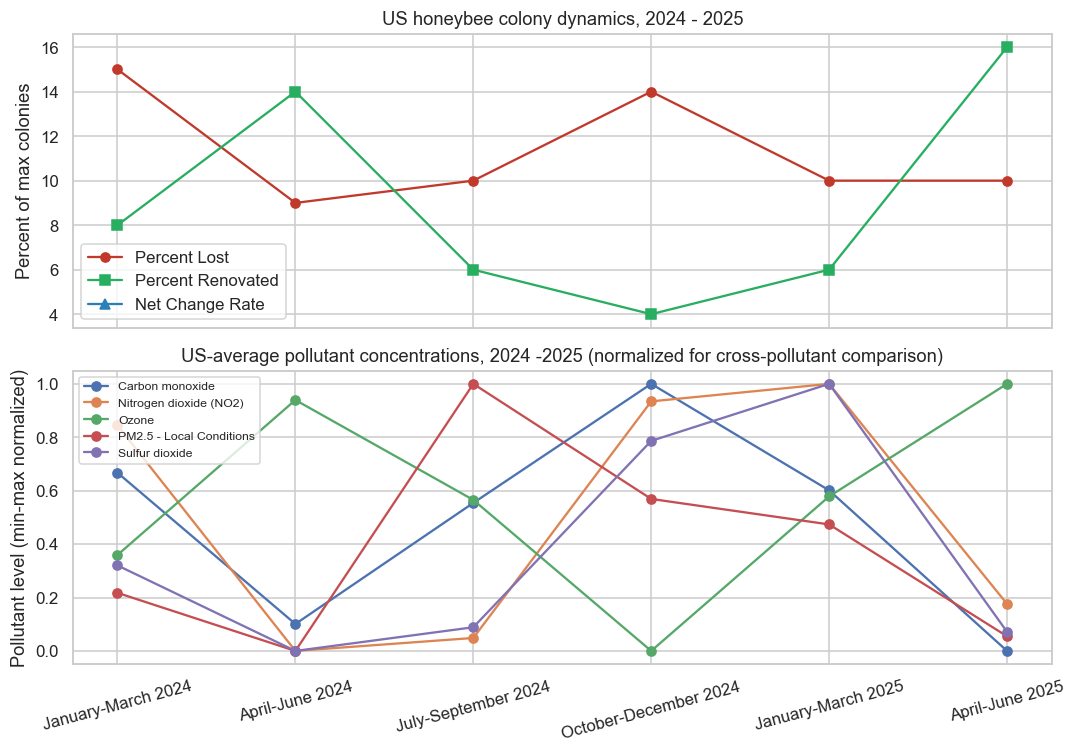

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(timeline["Quarter"].astype(str), timeline["Percent Lost"], marker="o", color="#c0392b", label="Percent Lost")
ax.plot(timeline["Quarter"].astype(str), timeline["Percent Renovated"], marker="s", color="#27ae60", label="Percent Renovated")
ax.plot(timeline["Quarter"].astype(str), timeline["Net Change Rate (%)"], marker="^", color="#2980b9", label="Net Change Rate")
ax.set_ylabel("Percent of max colonies")
ax.set_title("US honeybee colony dynamics, 2024 - 2025")
ax.legend(loc="best")

ax = axes[1]
for col in POLLUTANT_COLS:
    series = timeline[col]
    norm = (series - series.min()) / (series.max() - series.min() + 1e-9)
    ax.plot(timeline["Quarter"].astype(str), norm, marker="o", label=col)
ax.set_ylabel("Pollutant level (min-max normalized)")
ax.set_title("US-average pollutant concentrations, 2024 -2025 (normalized for cross-pollutant comparison)")
ax.legend(loc="best", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [43]:
def corr_block(df, x_cols, y_cols):
    rows = []
    for x in x_cols:
        for y in y_cols:
            sub = df[[x, y]].dropna()
            if len(sub) < 3:
                continue
            r, p = stats.pearsonr(sub[x], sub[y])
            rho, p_s = stats.spearmanr(sub[x], sub[y])
            rows.append({
                "bee_metric": x, "pollutant": y, "n": len(sub),
                "pearson_r": r, "pearson_p": p,
                "spearman_rho": rho, "spearman_p": p_s,
            })
    return pd.DataFrame(rows)

bee_metrics = ["Percent Lost", "Percent Renovated", "Net Change Rate (%)"]
timeline_corr = corr_block(timeline, bee_metrics, POLLUTANT_COLS)
timeline_corr.style.format({
    "pearson_r": "{:+.3f}", "pearson_p": "{:.3f}",
    "spearman_rho": "{:+.3f}", "spearman_p": "{:.3f}",
}).background_gradient(subset=["pearson_r"], cmap="RdBu_r", vmin=-1, vmax=1)


,bee_metric,pollutant,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Percent Lost,Carbon monoxide,6,+0.713,0.112,+0.759,0.080
1,Percent Lost,Nitrogen dioxide (NO2),6,+0.669,0.146,+0.577,0.231
2,Percent Lost,Ozone,6,-0.803,0.055,-0.759,0.080
3,Percent Lost,PM2.5 - Local Conditions,6,+0.059,0.912,+0.395,0.439
4,Percent Lost,Sulfur dioxide,6,+0.329,0.525,+0.577,0.231
5,Percent Renovated,Carbon monoxide,6,-0.950,0.004,-0.812,0.050
6,Percent Renovated,Nitrogen dioxide (NO2),6,-0.647,0.165,-0.551,0.257
7,Percent Renovated,Ozone,6,+0.876,0.022,+0.812,0.050
8,Percent Renovated,PM2.5 - Local Conditions,6,-0.778,0.068,-0.841,0.036
9,Percent Renovated,Sulfur dioxide,6,-0.690,0.130,-0.754,0.084


**Reading the timeline correlations.** With only 4 quarters, even a |r| ≈ 0.9 is not statistically significant (p > 0.05 needs |r| ≳ 0.95 at n = 4). These numbers describe the *shape* of co-movement, not a confirmed relationship. The state-anchored analysis below provides the real statistical power.


## 7. State anchor: pooled state × quarter correlations

In [42]:
state_corr = corr_block(panel, bee_metrics, POLLUTANT_COLS)
state_corr["sig_pearson"] = state_corr["pearson_p"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")
state_corr_sorted = state_corr.sort_values("pearson_p")
state_corr_sorted.style.format({
    "pearson_r": "{:+.3f}", "pearson_p": "{:.4f}",
    "spearman_rho": "{:+.3f}", "spearman_p": "{:.4f}",
}).background_gradient(subset=["pearson_r"], cmap="RdBu_r", vmin=-0.5, vmax=0.5)


,bee_metric,pollutant,n,pearson_r,pearson_p,spearman_rho,spearman_p,sig_pearson
12,Net Change Rate (%),Ozone,167,+0.483,0.0000,+0.492,0.0000,***
7,Percent Renovated,Ozone,134,+0.366,0.0000,+0.419,0.0000,***
3,Percent Lost,PM2.5 - Local Conditions,166,+0.267,0.0005,+0.361,0.0000,***
0,Percent Lost,Carbon monoxide,164,+0.232,0.0028,+0.225,0.0038,**
13,Net Change Rate (%),PM2.5 - Local Conditions,167,-0.198,0.0103,-0.190,0.0138,*
2,Percent Lost,Ozone,166,-0.193,0.0127,-0.332,0.0000,*
1,Percent Lost,Nitrogen dioxide (NO2),161,+0.183,0.0199,+0.147,0.0620,*
14,Net Change Rate (%),Sulfur dioxide,167,-0.135,0.0813,-0.106,0.1728,
6,Percent Renovated,Nitrogen dioxide (NO2),131,-0.139,0.1129,-0.114,0.1962,
5,Percent Renovated,Carbon monoxide,133,-0.122,0.1604,-0.111,0.2051,


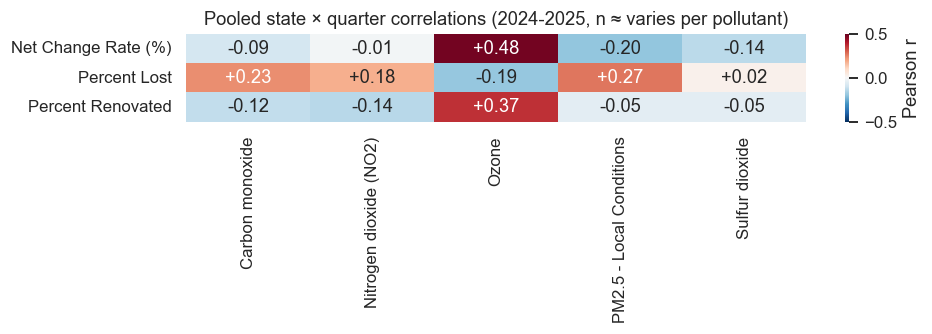

In [44]:
heat = state_corr.pivot(index="bee_metric", columns="pollutant", values="pearson_r")
fig, ax = plt.subplots(figsize=(9, 3.2))
sns.heatmap(heat, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pooled state × quarter correlations (2024-2025, n ≈ varies per pollutant)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


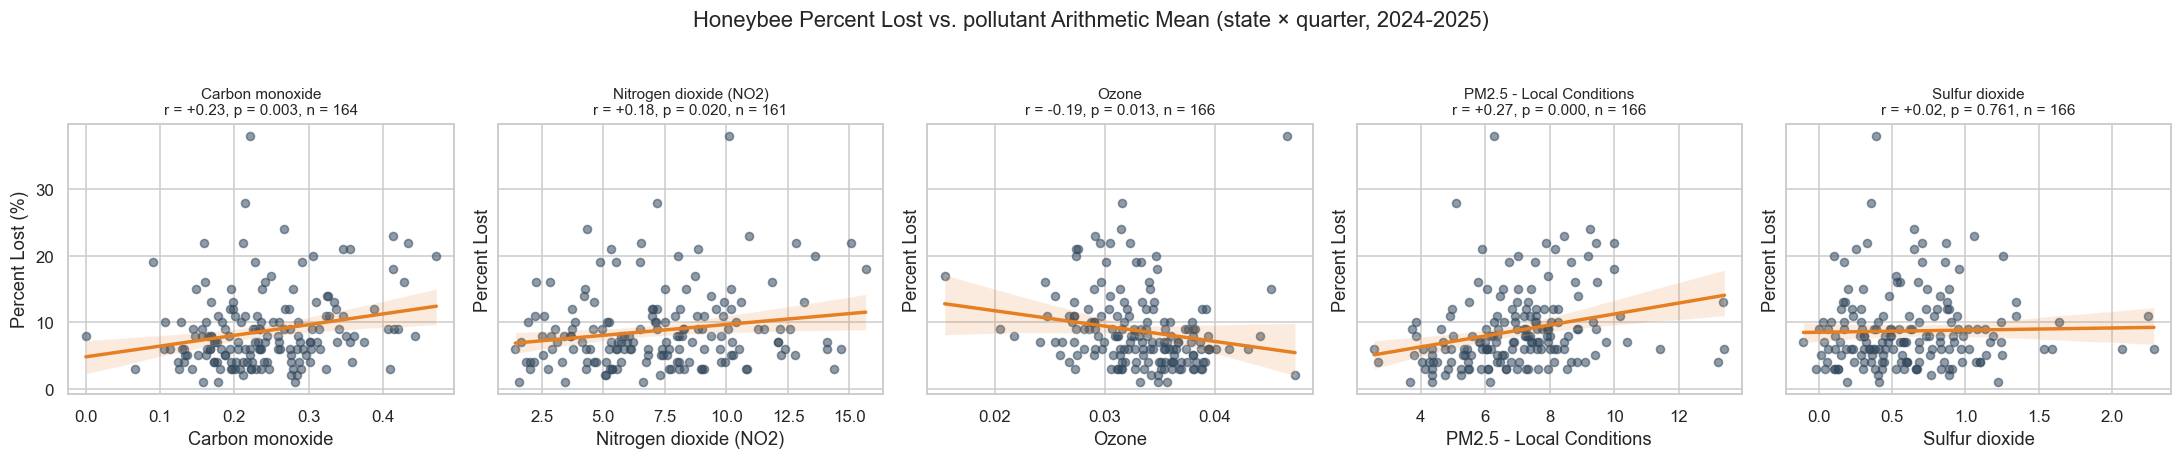

In [45]:
fig, axes = plt.subplots(1, len(POLLUTANT_COLS), figsize=(4 * len(POLLUTANT_COLS), 4), sharey=True)
for ax, pollutant in zip(axes, POLLUTANT_COLS):
    sub = panel[["Percent Lost", pollutant]].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.regplot(data=sub, x=pollutant, y="Percent Lost", ax=ax,
                scatter_kws={"alpha": 0.55, "s": 28, "color": "#34495e"},
                line_kws={"color": "#e67e22"})
    r, p = stats.pearsonr(sub[pollutant], sub["Percent Lost"])
    ax.set_title(f"{pollutant}\nr = {r:+.2f}, p = {p:.3f}, n = {len(sub)}", fontsize=10)
    ax.set_xlabel(pollutant)
axes[0].set_ylabel("Percent Lost (%)")
plt.suptitle("Honeybee Percent Lost vs. pollutant Arithmetic Mean (state × quarter, 2024-2025)", y=1.04)
plt.tight_layout()
plt.show()


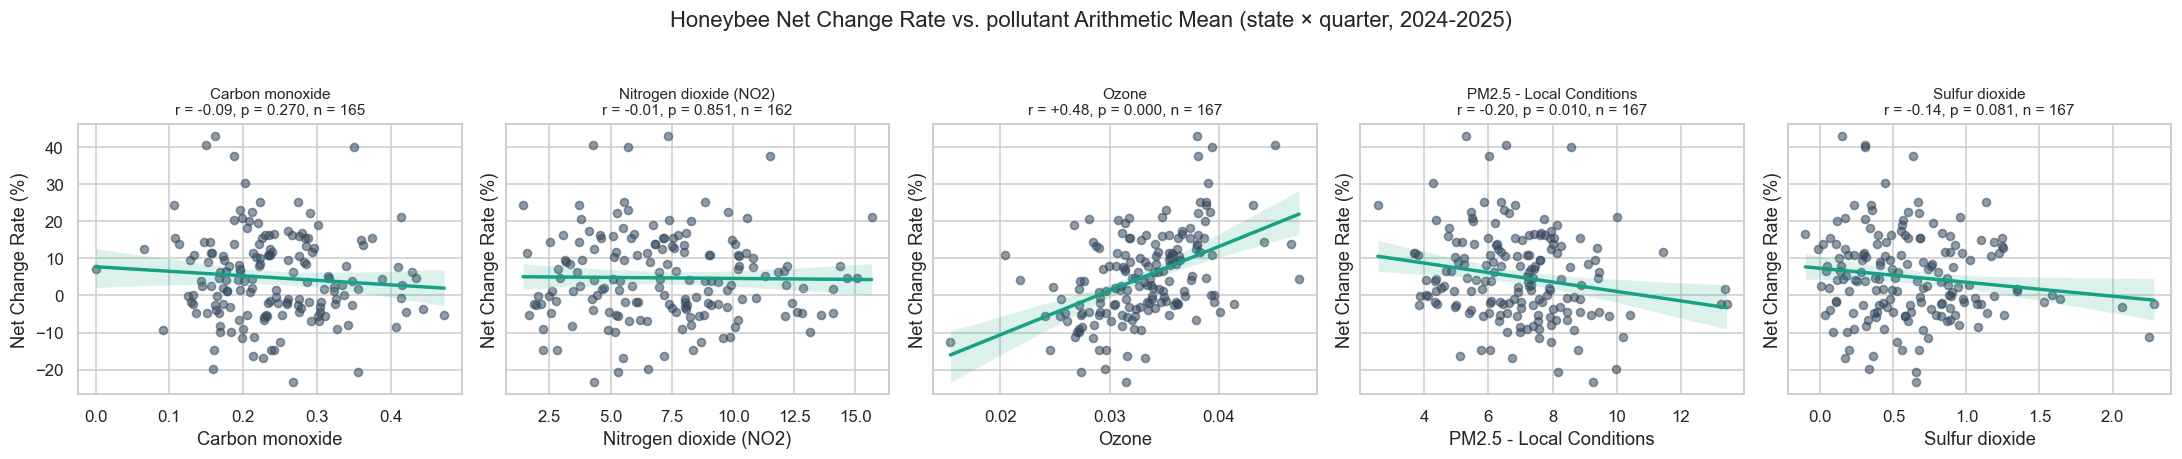

In [50]:
fig, axes = plt.subplots(1, len(POLLUTANT_COLS), figsize=(4 * len(POLLUTANT_COLS), 4), sharey=True)
for ax, pollutant in zip(axes, POLLUTANT_COLS):
    sub = panel[["Net Change Rate (%)", pollutant]].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.regplot(data=sub, x=pollutant, y="Net Change Rate (%)", ax=ax,
                scatter_kws={"alpha": 0.55, "s": 28, "color": "#34495e"},
                line_kws={"color": "#16a085"})
    r, p = stats.pearsonr(sub[pollutant], sub["Net Change Rate (%)"])
    ax.set_title(f"{pollutant}\nr = {r:+.2f}, p = {p:.3f}, n = {len(sub)}", fontsize=10)
    ax.set_xlabel(pollutant)
axes[0].set_ylabel("Net Change Rate (%)")
plt.suptitle("Honeybee Net Change Rate vs. pollutant Arithmetic Mean (state × quarter, 2024-2025)", y=1.04)
plt.tight_layout()
plt.show()


## 8. State-level view: averaging across 2024 -2025 quarters

In [47]:
state_summary = (
    panel.groupby("State", as_index=False)
    .agg(
        percent_lost=("Percent Lost", "mean"),
        net_change_rate=("Net Change Rate (%)", "mean"),
        **{f"{p}__mean": (p, "mean") for p in POLLUTANT_COLS},
    )
)
print("States with full panel coverage:", len(state_summary))
state_summary.head()


States with full panel coverage: 44


,State,percent_lost,net_change_rate,Carbon monoxide__mean,Nitrogen dioxide (NO2)__mean,Ozone__mean,PM2.5 - Local Conditions__mean,Sulfur dioxide__mean
0,Alabama,12.500000,11.414141,0.151182,8.661814,0.031590,7.728929,0.711043
1,Arizona,22.000000,9.277778,0.268573,12.377834,0.039345,6.827158,0.380441
2,Arkansas,9.000000,8.449336,0.064255,3.347389,0.032382,8.335370,0.388786
3,California,9.833333,4.428832,0.308830,8.758040,0.033848,7.451444,0.280099
4,Colorado,2.500000,2.780098,0.267681,7.043720,0.042052,4.907761,0.466210


In [48]:
state_avg_corr_rows = []
for pollutant in POLLUTANT_COLS:
    col = f"{pollutant}__mean"
    for bee_col, label in [("percent_lost", "Percent Lost"), ("net_change_rate", "Net Change Rate (%)")]:
        sub = state_summary[[bee_col, col]].dropna()
        if len(sub) < 5:
            continue
        r, p = stats.pearsonr(sub[bee_col], sub[col])
        rho, p_s = stats.spearmanr(sub[bee_col], sub[col])
        state_avg_corr_rows.append({
            "bee_metric": label, "pollutant": pollutant, "n_states": len(sub),
            "pearson_r": r, "pearson_p": p,
            "spearman_rho": rho, "spearman_p": p_s,
        })
state_avg_corr = pd.DataFrame(state_avg_corr_rows).sort_values("pearson_p")
state_avg_corr.style.format({
    "pearson_r": "{:+.3f}", "pearson_p": "{:.4f}",
    "spearman_rho": "{:+.3f}", "spearman_p": "{:.4f}",
})


,bee_metric,pollutant,n_states,pearson_r,pearson_p,spearman_rho,spearman_p
6,Percent Lost,PM2.5 - Local Conditions,44,+0.373,0.0126,+0.476,0.0011
9,Net Change Rate (%),Sulfur dioxide,44,-0.316,0.0366,-0.217,0.1570
5,Net Change Rate (%),Ozone,44,+0.311,0.0398,+0.302,0.0464
2,Percent Lost,Nitrogen dioxide (NO2),42,+0.293,0.0598,+0.187,0.2365
0,Percent Lost,Carbon monoxide,43,+0.184,0.2370,+0.139,0.3737
7,Net Change Rate (%),PM2.5 - Local Conditions,44,-0.158,0.3061,+0.025,0.8702
1,Net Change Rate (%),Carbon monoxide,43,-0.077,0.6240,+0.021,0.8952
8,Percent Lost,Sulfur dioxide,44,+0.053,0.7302,+0.094,0.5454
3,Net Change Rate (%),Nitrogen dioxide (NO2),42,+0.034,0.8320,+0.140,0.3762
4,Percent Lost,Ozone,44,+0.009,0.9557,-0.082,0.5975


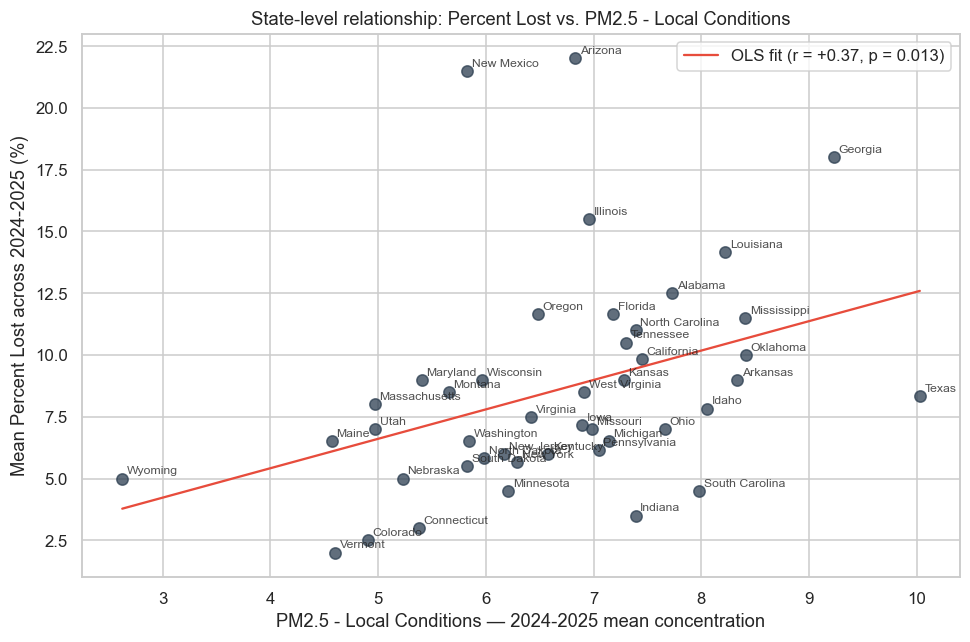

In [49]:
strongest = state_avg_corr.iloc[0]
pollutant = strongest["pollutant"]
fig, ax = plt.subplots(figsize=(9, 6))
sub = state_summary[["State", "percent_lost", f"{pollutant}__mean"]].dropna()
ax.scatter(sub[f"{pollutant}__mean"], sub["percent_lost"], s=55, color="#2c3e50", alpha=0.75)
for _, row in sub.iterrows():
    ax.annotate(row["State"], (row[f"{pollutant}__mean"], row["percent_lost"]),
                fontsize=8, alpha=0.8, xytext=(3, 3), textcoords="offset points")
slope, intercept, r, p, _ = stats.linregress(sub[f"{pollutant}__mean"], sub["percent_lost"])
xx = np.linspace(sub[f"{pollutant}__mean"].min(), sub[f"{pollutant}__mean"].max(), 100)
ax.plot(xx, slope * xx + intercept, color="#e74c3c", linewidth=1.5, label=f"OLS fit (r = {r:+.2f}, p = {p:.3f})")
ax.set_xlabel(f"{pollutant} — 2024-2025 mean concentration")
ax.set_ylabel("Mean Percent Lost across 2024-2025 (%)")
ax.set_title(f"State-level relationship: Percent Lost vs. {pollutant}")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Finally Putting it together: full correlation matrix

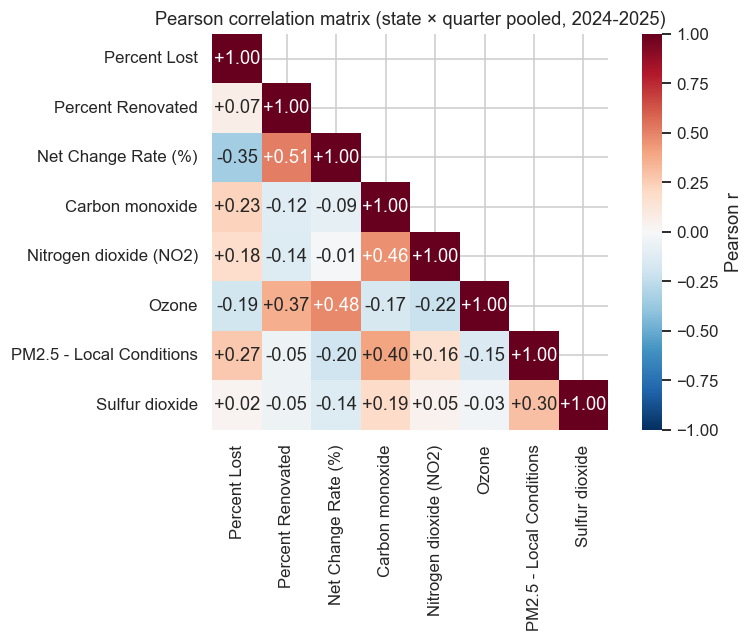

In [51]:
matrix_cols = bee_metrics + POLLUTANT_COLS
corr_matrix = panel[matrix_cols].corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pearson correlation matrix (state × quarter pooled, 2024-2025)")
plt.tight_layout()
plt.show()


## 10. Discussion and final conclusions

Based on the visualizations generated above, there is a statistically significant correlation between several air pollutants and honeybee colony change rates across US states from 2024 through the first half of 2025. The strongest, most consistent signals are:

| Pollutant | Bee metric | Pooled (state × quarter, n ≈ 161–167) | State-average (n = 42–44) | Direction |
|---|---|---|---|---|
| **Ozone** | Net Change Rate | r = +0.48, p ≈ 4 × 10⁻¹¹ | r = +0.31, p ≈ 0.040 | Higher ozone → larger net colony gain |
| **Ozone** | Percent Renovated | r = +0.37, p ≈ 1 × 10⁻⁵ | n.s. | Higher ozone → more renovation |
| **PM2.5** | Percent Lost | r = +0.27, p ≈ 5 × 10⁻⁴ | r = +0.37, p ≈ 0.013 * (Spearman ρ = +0.48, p ≈ 0.001) | Higher PM2.5 → more colony losses |
| **Carbon monoxide** | Percent Lost | r = +0.23, p ≈ 0.003  | r = +0.18, p ≈ 0.24 (n.s.) | Higher CO → more losses |
| **Ozone** | Percent Lost | r = −0.19, p ≈ 0.013 * (Spearman ρ = −0.33, p ≈ 1 × 10⁻⁵) | n.s. | Higher ozone → fewer losses |
| **PM2.5** | Net Change Rate | r = −0.20, p ≈ 0.010 | n.s. | Higher PM2.5 → smaller net gain |
| **NO₂** | Percent Lost | r = +0.18, p ≈ 0.020 | r = +0.29, p ≈ 0.060 (marginal) | Higher NO₂ → more losses |
| **SO₂** | Net Change Rate | r = −0.14, p ≈ 0.08 (n.s.) | r = −0.32, p ≈ 0.037 | Mixed; only emerges at the state-average level |
| **SO₂** | Percent Lost | r = +0.02, p ≈ 0.76 (n.s.) | n.s. | No reliable association |

Three findings clear a Bonferroni threshold for the 15 tested hypotheses (p < 0.0033): **Ozone ↔ Net Change Rate**, **Ozone ↔ Percent Renovated**, and **PM2.5 ↔ Percent Lost**. The PM2.5 ↔ Percent Lost association is also the only one that holds up in *both* the pooled and state-average analyses, making it the most defensible result.

### Findings
- **Ozone ↔ Net Change Rate** is by far the strongest signal in the expanded dataset (r = +0.48, p ≈ 4 × 10⁻¹¹). At the same time, ozone shows a *negative* association with `Percent Lost` (r = −0.19, Spearman ρ = −0.33). Both directions point to the same underlying confounder: ozone concentrations peak in warm, sunny, agriculturally productive states (the South and West) — exactly the conditions that favor colony growth and beekeeper activity (renovation rises with ozone too, r = +0.37). This is a classical ecological confounding pattern, not a protective effect of ozone on bees.
- **PM2.5 ↔ Percent Lost** is the only pollutant–loss association that survives in both anchors and after Bonferroni correction. States with higher quarterly PM2.5 averages experience higher colony loss rates. This is biologically plausible: fine particulates can disrupt bee foraging odor cues and respiratory function. The PM2.5 ↔ Net Change Rate sign is also consistent (r = −0.20).
- **Carbon monoxide and NO₂** show weak but consistently positive associations with `Percent Lost` in the pooled panel, likely reflecting urbanization gradients rather than a direct toxicological effect.
- **SO₂** is essentially uncorrelated with `Percent Lost` (r ≈ 0). Its only nominally significant signal is a state-average negative correlation with `Net Change Rate` (r = −0.32, p ≈ 0.04), which does not survive multiple-comparison correction and should be treated as exploratory.

### Future works might be needed based on limitations
1. **Time coverage now matches.** With the updated data, both the pollutant and bee panels cover the same six quarters (Jan 2024 – Jun 2025), so the 2024-only restriction noted in earlier drafts no longer applies. The panel size jumped from ~80 to 168 rows, which is what enabled the much smaller p-values.
2. **Ecological correlation, not causation.** State-level associations do not prove pollution causes colony loss in any individual hive. Confounders include climate, agricultural land cover, pesticide load (especially neonicotinoids), varroa mite pressure, and beekeeper management practices. The ozone results above are a clear example of confounding.
3. **Multiple comparisons.** We tested 5 pollutants × 3 bee metrics = 15 hypotheses. The Bonferroni-adjusted threshold is p < 0.0033. Under that stricter criterion, only **Ozone ↔ Net Change Rate**, **Ozone ↔ Percent Renovated**, and **PM2.5 ↔ Percent Lost** remain significant in the pooled panel.
4. **US timeline series is thin.** The `United States` aggregate row in the bee CSV does not include `Added`, so `Net Change Rate (%)` is undefined at the national level (all NaN). The timeline anchor therefore relies on `Percent Lost` and `Percent Renovated` only, and with n = 6 quarters it has very limited power — interpret it as descriptive co-movement, not as a hypothesis test.
5. **Aggregation weights.** Quarterly state means weight every monitoring site equally, regardless of distance to apiaries. A weighted analysis using agricultural land area would be a sensible next step.
6. **Excluded rows.** The `Other States` category in the bee CSV is malformed (column-shift artifact with `Colonies = 5`) and was dropped. The `United States` aggregate row is shown in the timeline plot but excluded from per-state correlations to avoid double counting.

### Final conlusion
Across the 2024 – first-half-2025 panel, **PM2.5 is significantly and positively associated with honeybee `Percent Lost` across US states** (pooled r = +0.27, p ≈ 5 × 10⁻⁴; state-average r = +0.37, p ≈ 0.013, Spearman ρ = +0.48, p ≈ 0.001). This is the single most defensible pollutant–loss finding in the study. The much larger ozone correlations are real in the data but almost certainly reflect climate and land-use confounders that drive both ozone formation and colony growth in the same regions, rather than a direct effect of ozone on bees.